In [88]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("C:/Users/billn/Downloads/Projet_TI508A_2025/patients_synthetic_1000.csv")

# aperçu
print(df.shape)
display(df.head())
display(df.info())

(1000, 17)


,patient_id,age,sex,smoker,physical_activity,diet_quality,bmi,systolic_bp,diastolic_bp,glucose_fasting,hba1c,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,diabetes,risk_category
0,1,55,Female,Yes,Medium,Poor,33.7,129,85,113.2,4.75,226,47,129,234,No,Moderate
1,2,32,Male,Yes,Medium,Poor,28.9,99,62,98.2,4.69,177,25,135,109,No,Low
2,3,63,Male,No,Low,Average,21.3,104,72,93.6,5.03,167,58,75,116,No,Low
3,4,66,Male,No,Low,Poor,31.3,131,87,114.2,5.37,220,50,150,105,No,Moderate
4,5,18,Male,No,Medium,Good,27.4,95,61,88.3,4.98,142,63,55,172,No,Low


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_id         1000 non-null   int64  
 1   age                1000 non-null   int64  
 2   sex                1000 non-null   object 
 3   smoker             1000 non-null   object 
 4   physical_activity  1000 non-null   object 
 5   diet_quality       1000 non-null   object 
 6   bmi                1000 non-null   float64
 7   systolic_bp        1000 non-null   int64  
 8   diastolic_bp       1000 non-null   int64  
 9   glucose_fasting    1000 non-null   float64
 10  hba1c              1000 non-null   float64
 11  cholesterol_total  1000 non-null   int64  
 12  hdl_cholesterol    1000 non-null   int64  
 13  ldl_cholesterol    1000 non-null   int64  
 14  triglycerides      1000 non-null   int64  
 15  diabetes           1000 non-null   object 
 16  risk_category      1000 n

None

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Lire le fichier CSV
df = pd.read_csv("C:/Users/billn/Downloads/Projet_TI508A_2025/patients_synthetic_1000.csv")

# -------------------------------
# 1. Description du Jeu de Données
# -------------------------------

print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

print("\nTypes des colonnes :")
print(df.dtypes)

# Identifier variables continues vs catégoriques
continues = df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical = df.select_dtypes(include=['object','category']).columns.tolist()
print("\nVariables continues :", continues)
print("Variables catégoriques :", categorical)

Nombre de lignes : 1000
Nombre de colonnes : 17

Types des colonnes :
patient_id             int64
age                    int64
sex                   object
smoker                object
physical_activity     object
diet_quality          object
bmi                  float64
systolic_bp            int64
diastolic_bp           int64
glucose_fasting      float64
hba1c                float64
cholesterol_total      int64
hdl_cholesterol        int64
ldl_cholesterol        int64
triglycerides          int64
diabetes              object
risk_category         object
dtype: object

Variables continues : ['patient_id', 'age', 'bmi', 'systolic_bp', 'diastolic_bp', 'glucose_fasting', 'hba1c', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides']
Variables catégoriques : ['sex', 'smoker', 'physical_activity', 'diet_quality', 'diabetes', 'risk_category']


In [90]:
# 2.1 Détecter les données manquantes
print("\nNombre de valeurs manquantes par colonne :")
print(df.isnull().sum())

# Remplir les valeurs manquantes numériques par la médiane
for col in continues:
    df[col] = df[col].fillna(df[col].median())

# Remplir les valeurs manquantes catégoriques par la valeur la plus fréquente
for col in categorical:
    df[col] = df[col].fillna(df[col].mode()[0])


Nombre de valeurs manquantes par colonne :
patient_id           0
age                  0
sex                  0
smoker               0
physical_activity    0
diet_quality         0
bmi                  0
systolic_bp          0
diastolic_bp         0
glucose_fasting      0
hba1c                0
cholesterol_total    0
hdl_cholesterol      0
ldl_cholesterol      0
triglycerides        0
diabetes             0
risk_category        0
dtype: int64



Statistiques descriptives des variables continues :
        patient_id         age          bmi  systolic_bp  diastolic_bp  \
count  1000.000000  1000.00000  1000.000000  1000.000000   1000.000000   
mean    500.500000    49.68300    28.617300   117.693000     73.691000   
std     288.819436    16.18408     5.219095    13.649581      8.209075   
min       1.000000    18.00000    16.000000    85.000000     50.000000   
25%     250.750000    38.00000    25.100000   108.000000     68.000000   
50%     500.500000    50.00000    28.600000   118.000000     73.000000   
75%     750.250000    60.00000    32.225000   127.000000     79.000000   
max    1000.000000    90.00000    44.200000   164.000000    101.000000   

       glucose_fasting        hba1c  cholesterol_total  hdl_cholesterol  \
count      1000.000000  1000.000000        1000.000000      1000.000000   
mean        101.677700     4.849330         193.668000        51.220000   
std          14.620435     0.304421          37.471481 

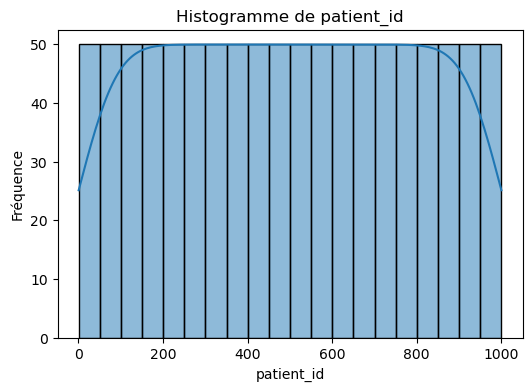

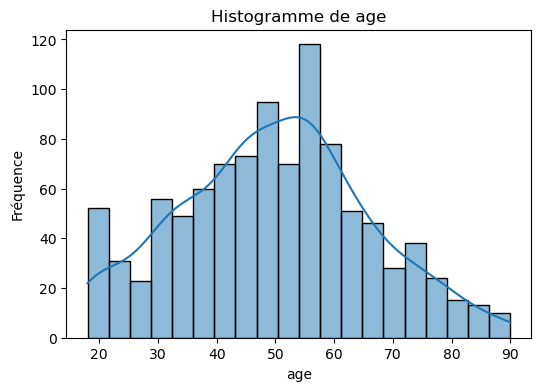

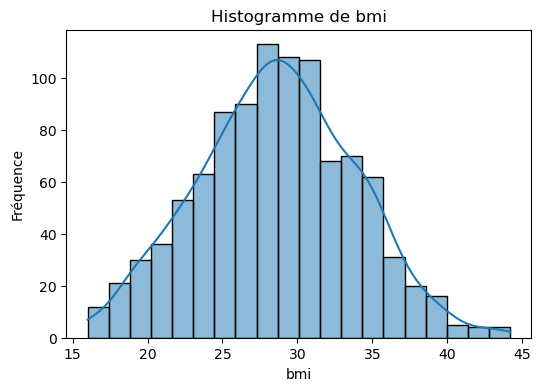

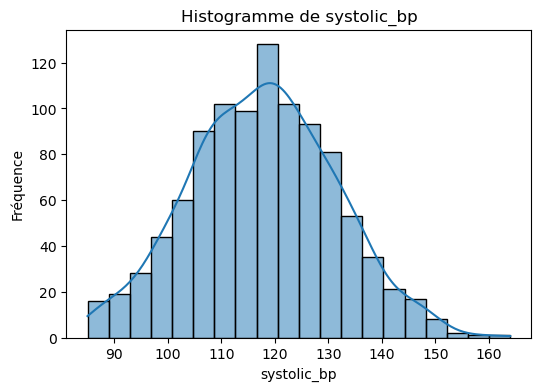

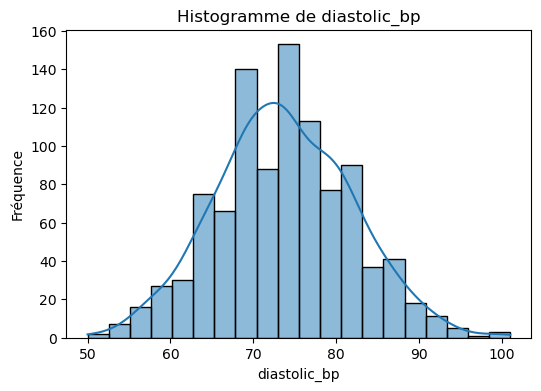

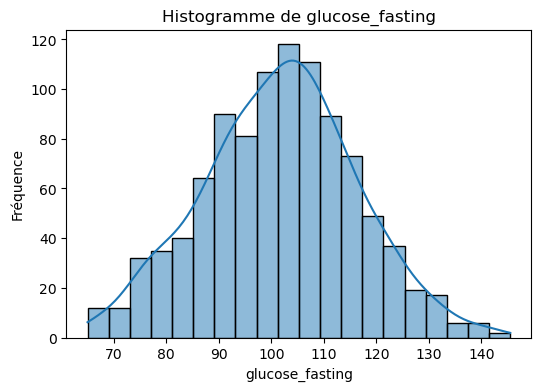

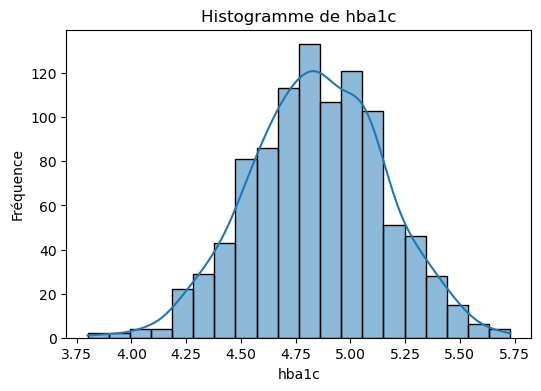

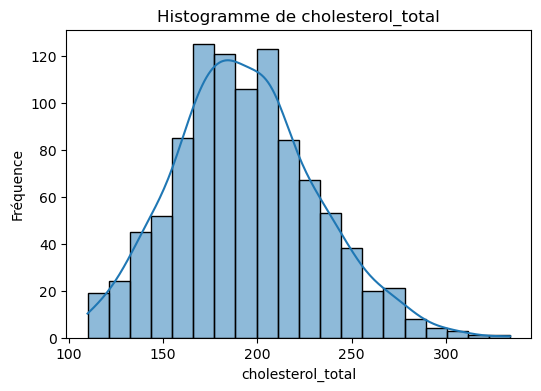

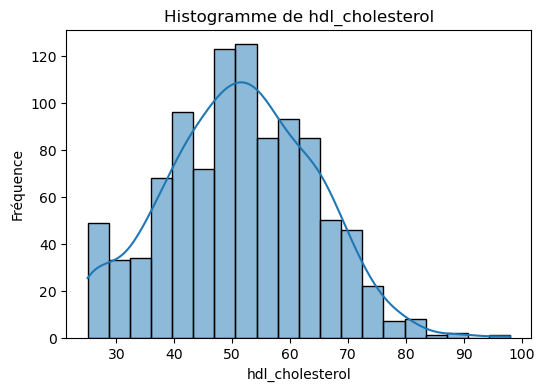

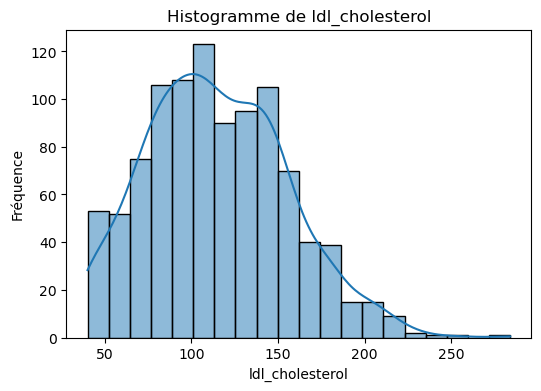

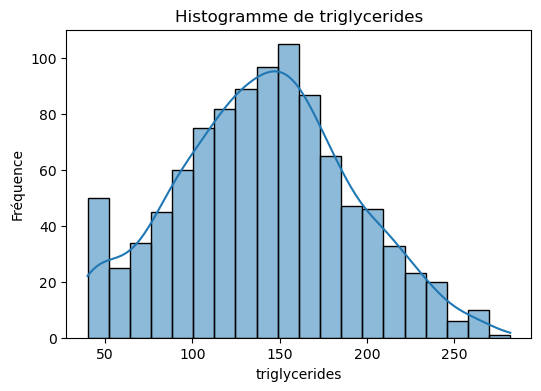

In [91]:
# 2.2 Analyse descriptive des variables continues
print("\nStatistiques descriptives des variables continues :")
print(df[continues].describe())

for col in continues:
    print(f"{col} -> Moyenne: {df[col].mean():.2f}, Médiane: {df[col].median():.2f}, Écart-type: {df[col].std():.2f}")

# Visualisation : histogrammes pour chaque variable continue
for col in continues:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Histogramme de {col}')
    plt.xlabel(col)
    plt.ylabel('Fréquence')
    plt.show()

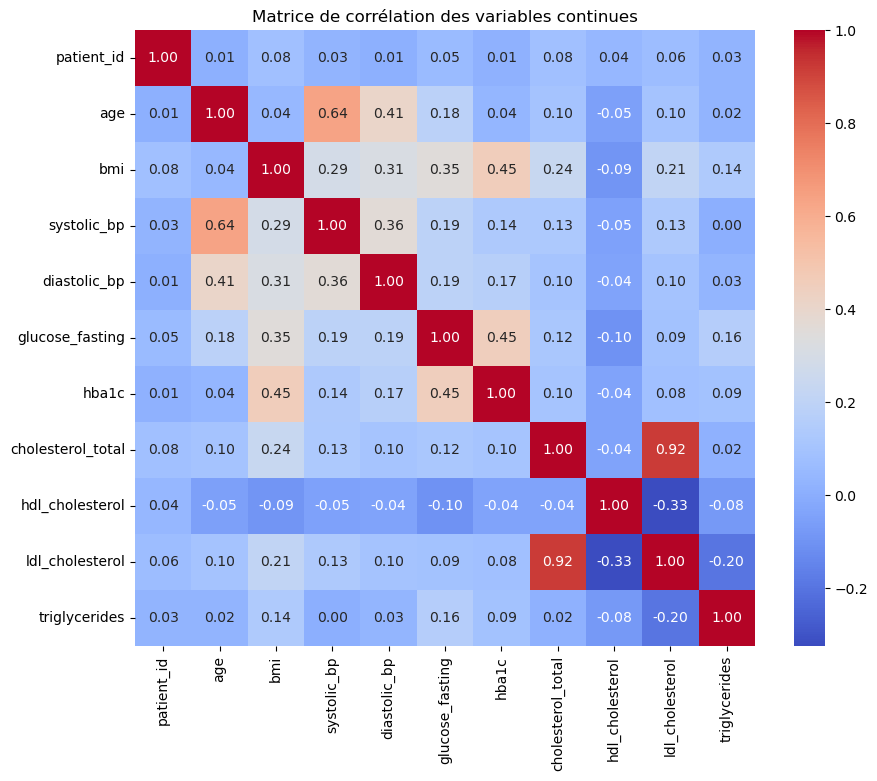

In [92]:
# 2.3 Visualiser les corrélations entre variables continues
plt.figure(figsize=(10,8))
correlation_matrix = df[continues].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de corrélation des variables continues")
plt.show()

    On observe une forte correlation entre des variables  a l'instar de:
    ldl_cholesterol et cholesterol_total
    Age et systolic_bp
    
    

In [93]:
import os
# Limiter le nombre de threads MKL pour éviter les warnings
os.environ["OMP_NUM_THREADS"] = "4"

import warnings
# Ignorer les warnings spécifiques KMeans
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak on Windows")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.decomposition import PCA

# -------------------------------
# Lecture des données
# -------------------------------

# Sélection des variables continues
continues = df.select_dtypes(include=['int64','float64']).columns.tolist()
X = df[continues]

# -------------------------------
# 1. Normalisation des données
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Kmeans

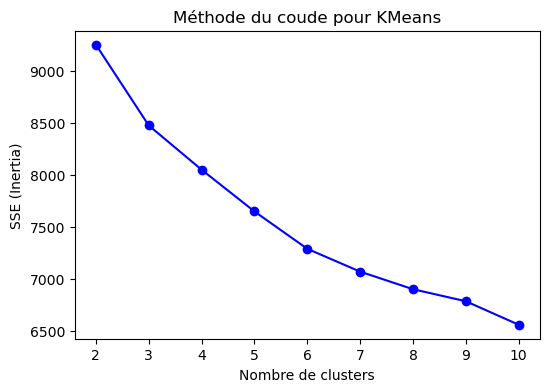

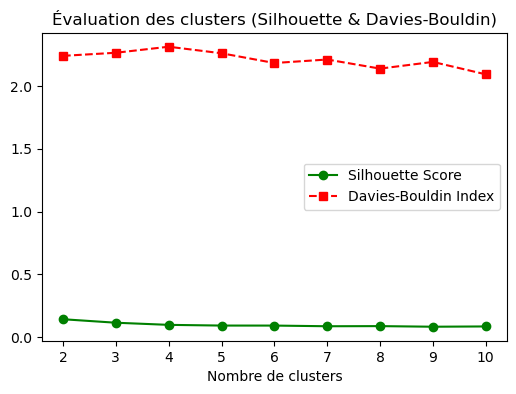

Nombre optimal de clusters : 2
Silhouette Score (KMeans) : 0.142
Davies-Bouldin Index (KMeans) : 2.240

Moyennes des variables par cluster (KMeans) :
                patient_id        age        bmi  systolic_bp  diastolic_bp  \
KMeans_Cluster                                                                
0               551.190083  57.555785  31.404752   125.092975     77.772727   
1               452.953488  42.298450  26.002713   110.751938     69.862403   

                glucose_fasting     hba1c  cholesterol_total  hdl_cholesterol  \
KMeans_Cluster                                                                  
0                    108.630785  4.973926         208.307851        48.400826   
1                     95.155814  4.732461         179.936047        53.864341   

                ldl_cholesterol  triglycerides  
KMeans_Cluster                                  
0                    130.657025     147.993802  
1                     99.794574     134.308140  


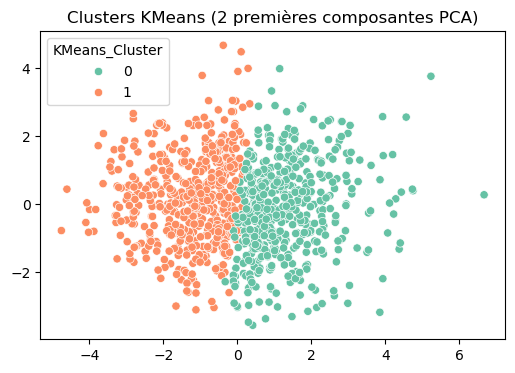

In [94]:
# 2.1 Méthode du coude
sse = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_range, sse, 'o-', color='blue')
plt.xlabel("Nombre de clusters")
plt.ylabel("SSE (Inertia)")
plt.title("Méthode du coude pour KMeans")
plt.show()

# 2.2 Silhouette Score et Davies-Bouldin Index
silhouette_scores = []
davies_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    davies_scores.append(davies_bouldin_score(X_scaled, labels))

plt.figure(figsize=(6,4))
plt.plot(k_range, silhouette_scores, 'o-', color='green', label='Silhouette Score')
plt.plot(k_range, davies_scores, 's--', color='red', label='Davies-Bouldin Index')
plt.xlabel("Nombre de clusters")
plt.title("Évaluation des clusters (Silhouette & Davies-Bouldin)")
plt.legend()
plt.show()

# Choisir k optimal selon Silhouette (max) ou Davies-Bouldin (min)
optimal_k = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f"Nombre optimal de clusters : {optimal_k}")

# 2.3 Application finale de KMeans
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

# Évaluation des clusters
sil_score = silhouette_score(X_scaled, df['KMeans_Cluster'])
db_score = davies_bouldin_score(X_scaled, df['KMeans_Cluster'])
print(f"Silhouette Score (KMeans) : {sil_score:.3f}")
print(f"Davies-Bouldin Index (KMeans) : {db_score:.3f}")

# Interprétation des clusters : moyenne des variables par cluster
print("\nMoyennes des variables par cluster (KMeans) :")
print(df.groupby('KMeans_Cluster')[continues].mean())

# Visualisation PCA des clusters
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(6,4))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['KMeans_Cluster'], palette='Set2')
plt.title("Clusters KMeans (2 premières composantes PCA)")
plt.show()






GMM (Gaussian Mixture Model)

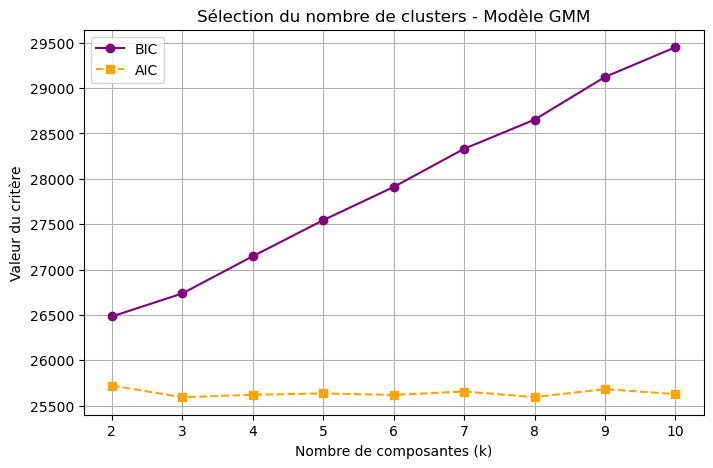

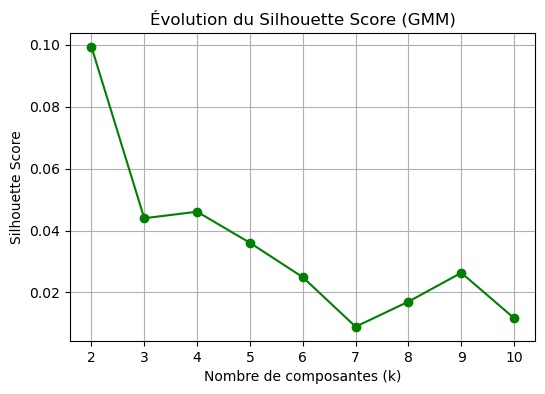

✅ Nombre optimal de clusters selon BIC : 2
Silhouette Score (GMM) : 0.099
Davies-Bouldin Index (GMM) : 2.761


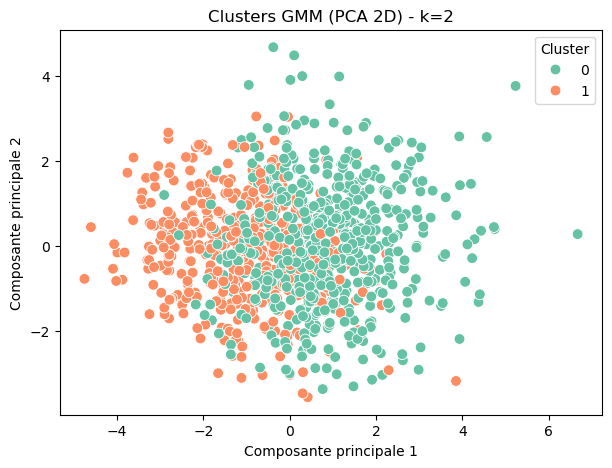


Moyennes des variables par cluster (GMM) :
             patient_id    age    bmi  systolic_bp  diastolic_bp  \
GMM_Cluster                                                        
0                632.40  55.73  30.37       122.88         76.03   
1                351.17  42.84  26.63       111.82         71.04   

             glucose_fasting  hba1c  cholesterol_total  hdl_cholesterol  \
GMM_Cluster                                                               
0                     104.64   4.89             208.34            49.75   
1                      98.33   4.80             177.06            52.88   

             ldl_cholesterol  triglycerides  
GMM_Cluster                                  
0                     130.11         141.04  
1                      97.32         140.81  


In [95]:
#GMM
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
import seaborn as sns



k_range = range(2, 11)
bic_scores, aic_scores, sil_scores = [], [], []

for k in k_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)

    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))
    sil_scores.append(silhouette_score(X_scaled, labels))

# ======================
# 2️⃣ Visualisation des critères d’évaluation
# ======================
plt.figure(figsize=(8,5))
plt.plot(k_range, bic_scores, 'o-', label='BIC', color='purple')
plt.plot(k_range, aic_scores, 's--', label='AIC', color='orange')
plt.title("Sélection du nombre de clusters - Modèle GMM")
plt.xlabel("Nombre de composantes (k)")
plt.ylabel("Valeur du critère")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(k_range, sil_scores, 'o-', color='green')
plt.title("Évolution du Silhouette Score (GMM)")
plt.xlabel("Nombre de composantes (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

# ======================
# 3️⃣ Choix du k optimal selon le BIC minimum
# ======================
optimal_k = k_range[np.argmin(bic_scores)]
print(f"✅ Nombre optimal de clusters selon BIC : {optimal_k}")

# ======================
# 4️⃣ Application finale du GMM
# ======================
gmm_final = GaussianMixture(n_components=optimal_k, covariance_type='full', random_state=42)
df['GMM_Cluster'] = gmm_final.fit_predict(X_scaled)

# Évaluation
sil_score_val = silhouette_score(X_scaled, df['GMM_Cluster'])
db_score_val = davies_bouldin_score(X_scaled, df['GMM_Cluster'])

print(f"Silhouette Score (GMM) : {sil_score_val:.3f}")
print(f"Davies-Bouldin Index (GMM) : {db_score_val:.3f}")

# ======================
# 5️⃣ Visualisation PCA des clusters
# ======================
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['GMM_Cluster'], palette='Set2', s=60)
plt.title(f"Clusters GMM (PCA 2D) - k={optimal_k}")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.legend(title="Cluster", bbox_to_anchor=(1, 1))
plt.show()

# ======================
# 6️⃣ Interprétation des clusters
# ======================
print("\nMoyennes des variables par cluster (GMM) :")
print(df.groupby('GMM_Cluster')[continues].mean().round(2))



Classification ascendante hiérarchique (CHA)

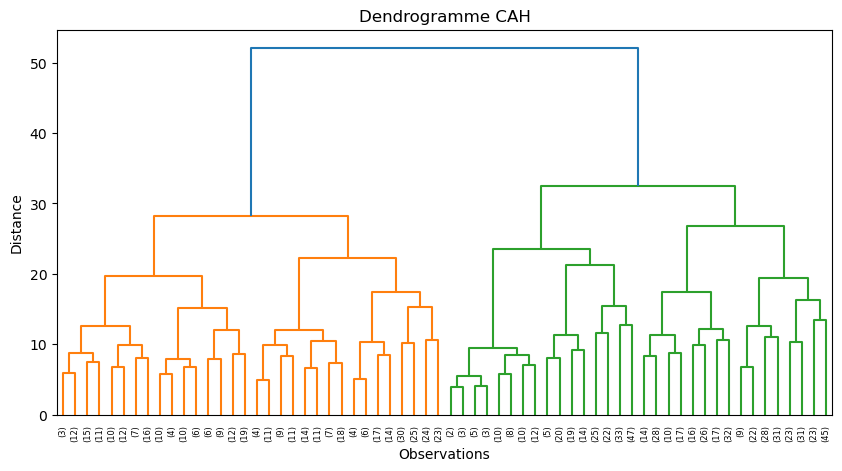

Silhouette Score (CAH) : 0.115
Davies-Bouldin Index (CAH) : 2.531

Moyennes des variables par cluster (CAH) :
             patient_id        age        bmi  systolic_bp  diastolic_bp  \
CAH_Cluster                                                                
1            558.717949  59.684615  30.818462   126.817949     78.474359   
2            463.278689  43.288525  27.210000   111.859016     70.632787   

             glucose_fasting     hba1c  cholesterol_total  hdl_cholesterol  \
CAH_Cluster                                                                  
1                 107.447436  4.924103         208.205128        46.338462   
2                  97.988852  4.801525         184.373770        54.340984   

             ldl_cholesterol  triglycerides  
CAH_Cluster                                  
1                 133.735897     142.884615  
2                 102.581967     139.683607  


In [96]:
#Classification ascendante hiérarchique (CHA)
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

# 3.1 Calcul de la matrice de linkage
Z = linkage(X_scaled, method='ward')

# 3.2 Dendrogramme
plt.figure(figsize=(10,5))
dendrogram(Z, truncate_mode='level', p=5)
plt.title("Dendrogramme CAH")
plt.xlabel("Observations")
plt.ylabel("Distance")
plt.show()

# 3.3 Découpage en clusters (même nombre que KMeans)
df['CAH_Cluster'] = fcluster(Z, t=optimal_k, criterion='maxclust')

# Évaluation des clusters CAH
sil_score_cah = silhouette_score(X_scaled, df['CAH_Cluster'])
db_score_cah = davies_bouldin_score(X_scaled, df['CAH_Cluster'])
print(f"Silhouette Score (CAH) : {sil_score_cah:.3f}")
print(f"Davies-Bouldin Index (CAH) : {db_score_cah:.3f}")

# Interprétation des clusters CAH : moyenne des variables par cluster
print("\nMoyennes des variables par cluster (CAH) :")
print(df.groupby('CAH_Cluster')[continues].mean())

Evaluation et comparaison des methodes

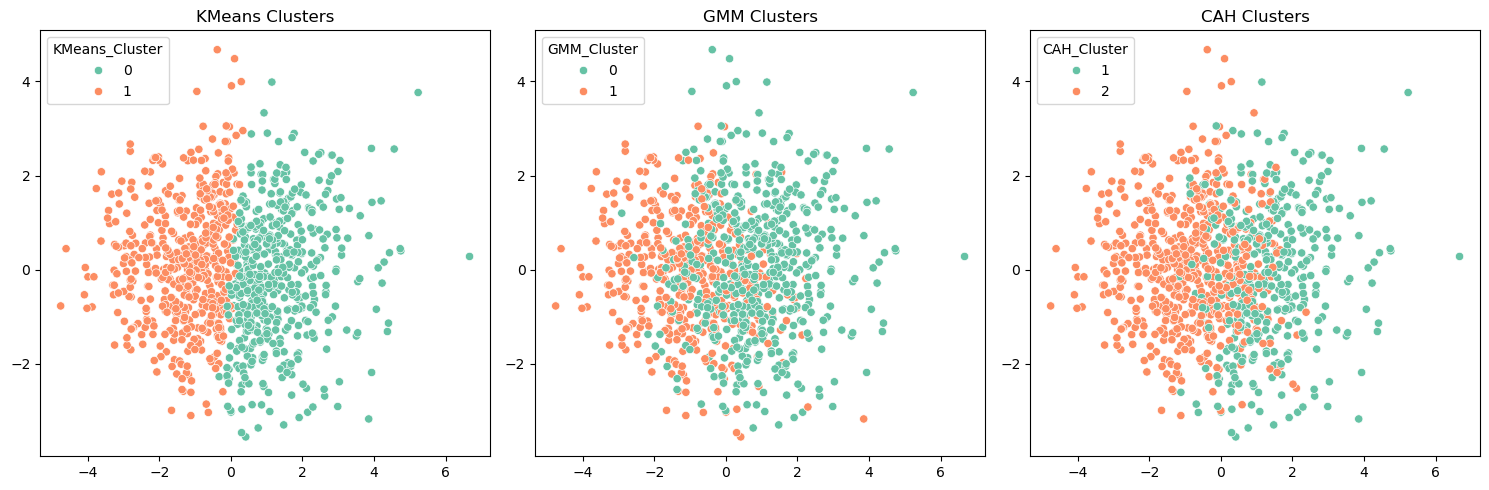


 Comparaison des méthodes de clustering :
  Méthode  Clusters  Silhouette  Davies-Bouldin
0  KMeans         2       0.142           2.240
2     CAH         2       0.115           2.531
1     GMM         2       0.099           2.761


In [97]:
#comparaison graphique
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['KMeans_Cluster'], palette='Set2', ax=axes[0])
axes[0].set_title("KMeans Clusters")

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['GMM_Cluster'], palette='Set2', ax=axes[1])
axes[1].set_title("GMM Clusters")

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['CAH_Cluster'], palette='Set2', ax=axes[2])
axes[2].set_title("CAH Clusters")

plt.tight_layout()
plt.show()

#tableau comparatif
import pandas as pd

results = pd.DataFrame({
    'Méthode': ['KMeans', 'GMM', 'CAH'],
    'Clusters': [2, 2, 2],
    'Silhouette': [0.142, 0.099, 0.115],
    'Davies-Bouldin': [2.240, 2.761, 2.531]
})

print("\n Comparaison des méthodes de clustering :")
print(results.sort_values(by='Silhouette', ascending=False))


Interprétation :

Le KMeans présente la meilleure cohésion intra-cluster (Silhouette la plus élevée) et la meilleure séparation inter-cluster (Davies-Bouldin le plus faible).

Le CAH (clustering hiérarchique) donne des résultats proches, ce qui suggère une structure similaire.

Le GMM montre une séparation moins nette, probablement due à des clusters qui se chevauchent ou à une variabilité plus forte dans les données.

➡️ Conclusion partielle :
Les données semblent mieux représentées par une segmentation en 2 groupes distincts avec une structure sphérique, ce qui est cohérent avec la nature du KMeans.

4.Régression Linéaire Simple et Multiple

Identifier des variables continues pertinentes

In [98]:
import pandas as pd

df = pd.read_csv("C:/Users/billn/Downloads/Projet_TI508A_2025/patients_synthetic_1000.csv")

# Sélection des variables continues
num_cols = df.select_dtypes(include=['float64','int64'])
corr = num_cols.corr()

# Affichage de la matrice de corrélation
print("Matrice de corrélation :")
display(corr.round(2))

Matrice de corrélation :


,patient_id,age,bmi,systolic_bp,diastolic_bp,glucose_fasting,hba1c,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides
patient_id,1.00,0.01,0.08,0.03,0.01,0.05,0.01,0.08,0.04,0.06,0.03
age,0.01,1.00,0.04,0.64,0.41,0.18,0.04,0.10,-0.05,0.10,0.02
bmi,0.08,0.04,1.00,0.29,0.31,0.35,0.45,0.24,-0.09,0.21,0.14
systolic_bp,0.03,0.64,0.29,1.00,0.36,0.19,0.14,0.13,-0.05,0.13,0.00
diastolic_bp,0.01,0.41,0.31,0.36,1.00,0.19,0.17,0.10,-0.04,0.10,0.03
glucose_fasting,0.05,0.18,0.35,0.19,0.19,1.00,0.45,0.12,-0.10,0.09,0.16
hba1c,0.01,0.04,0.45,0.14,0.17,0.45,1.00,0.10,-0.04,0.08,0.09
cholesterol_total,0.08,0.10,0.24,0.13,0.10,0.12,0.10,1.00,-0.04,0.92,0.02
hdl_cholesterol,0.04,-0.05,-0.09,-0.05,-0.04,-0.10,-0.04,-0.04,1.00,-0.33,-0.08
ldl_cholesterol,0.06,0.10,0.21,0.13,0.10,0.09,0.08,0.92,-0.33,1.00,-0.20


Ajuster un modèle de régression

Intercept : -3.169196224465935
Coefficient : 21.620903552545595
R² : 0.20266338174266618

Équation de la droite de régression :
y = -3.17 + 21.62 × hba1c


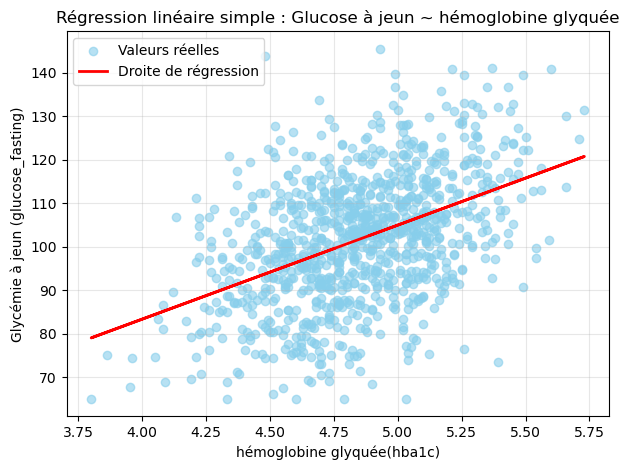

In [99]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# Variable cible (Y) et explicative (X)
X = df[['hba1c']]
y = df['glucose_fasting']

# Création et entraînement du modèle
model_simple = LinearRegression()
model_simple.fit(X, y)

# Prédictions
y_pred = model_simple.predict(X)

# Coefficients
print("Intercept :", model_simple.intercept_)
print("Coefficient :", model_simple.coef_[0])

# Coefficient de détermination R²
r2 = model_simple.score(X, y)
print("R² :", r2)

intercept = model_simple.intercept_
coef = model_simple.coef_[0]

#Équation de la droite
equation = f"y = {intercept:.2f} + {coef:.2f} × hba1c"
print("\nÉquation de la droite de régression :")
print(equation)

# ==========================
# 🔹 Visualisation du modèle
# ==========================

plt.figure(figsize=(7, 5))

# Nuage de points réels
plt.scatter(X, y, color='skyblue', alpha=0.6, label="Valeurs réelles")

# Droite de régression
plt.plot(X, y_pred, color='red', linewidth=2, label="Droite de régression")

# Titres et labels
plt.title("Régression linéaire simple : Glucose à jeun ~ hémoglobine glyquée")
plt.xlabel("hémoglobine glyquée(hba1c)")
plt.ylabel("Glycémie à jeun (glucose_fasting)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


Régression linéaire multiple

Intercept : -5.89

Coefficients du modèle :
bmi                   0.487
age                   0.145
hba1c                17.468
cholesterol_total     0.009
dtype: float64

R² : 0.257

Équation du modèle de régression multiple :
y = -5.89 + 0.49×bmi + 0.14×age + 17.47×hba1c + 0.01×cholesterol_total


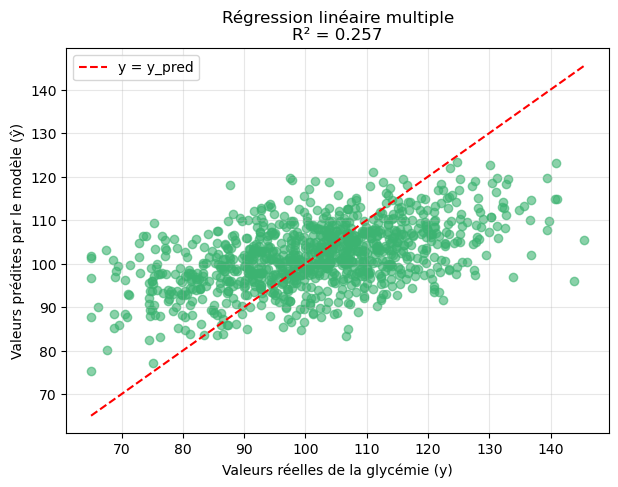

In [100]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
#  Préparation des données
# ===============================
X_multi = df[['bmi', 'age', 'hba1c', 'cholesterol_total']]
y = df['glucose_fasting']

# ===============================
#  Création et entraînement du modèle
# ===============================
model_multi = LinearRegression()
model_multi.fit(X_multi, y)

# ===============================
#  Prédictions et scores
# ===============================
y_pred_multi = model_multi.predict(X_multi)
r2_multi = model_multi.score(X_multi, y)

# ===============================
#  Coefficients et équation
# ===============================
coeffs = pd.Series(model_multi.coef_, index=X_multi.columns)
intercept = model_multi.intercept_

print("Intercept :", round(intercept, 3))  # ordonnée à l'origine
print("\nCoefficients du modèle :")
print(coeffs.round(3))
print(f"\nR² : {r2_multi:.3f}")

# Construction de l'équation lisible
equation_terms = [f"{coef:.2f}×{col}" for col, coef in zip(X_multi.columns, model_multi.coef_)]
equation = f"y = {intercept:.2f} + " + " + ".join(equation_terms)
print("\nÉquation du modèle de régression multiple :")
print(equation)

# ===============================
#  Visualisation
# ===============================

plt.figure(figsize=(7,5))

# Graphique réel vs prédit
plt.scatter(y, y_pred_multi, color='mediumseagreen', alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label="y = y_pred")

plt.xlabel("Valeurs réelles de la glycémie (y)")
plt.ylabel("Valeurs prédites par le modèle (ŷ)")
plt.title(f"Régression linéaire multiple\nR² = {r2_multi:.3f}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



Intercept : 3.627

Coefficients du modèle :
bmi                  0.020
age                 -0.001
glucose_fasting      0.007
cholesterol_total   -0.000
dtype: float64

R² : 0.303

Équation du modèle de régression multiple :
y = 3.63 + 0.02×bmi + -0.00×age + 0.01×glucose_fasting + -0.00×cholesterol_total


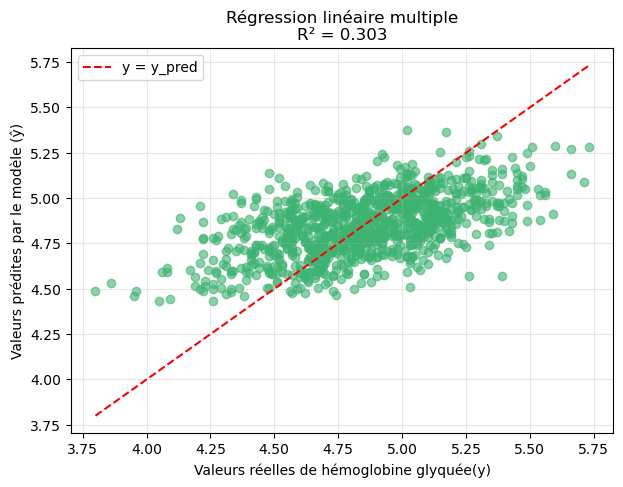

In [101]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
#  Préparation des données
# ===============================
X_multi = df[['bmi', 'age','glucose_fasting', 'cholesterol_total']]
y = df['hba1c']

# ===============================
#  Création et entraînement du modèle
# ===============================
model_multi = LinearRegression()
model_multi.fit(X_multi, y)

# ===============================
#  Prédictions et scores
# ===============================
y_pred_multi = model_multi.predict(X_multi)
r2_multi = model_multi.score(X_multi, y)

# ===============================
#  Coefficients et équation
# ===============================
coeffs = pd.Series(model_multi.coef_, index=X_multi.columns)
intercept = model_multi.intercept_

print("Intercept :", round(intercept, 3))  # ordonnée à l'origine
print("\nCoefficients du modèle :")
print(coeffs.round(3))
print(f"\nR² : {r2_multi:.3f}")

# Construction de l'équation lisible
equation_terms = [f"{coef:.2f}×{col}" for col, coef in zip(X_multi.columns, model_multi.coef_)]
equation = f"y = {intercept:.2f} + " + " + ".join(equation_terms)
print("\nÉquation du modèle de régression multiple :")
print(equation)

# ===============================
#  Visualisation
# ===============================

plt.figure(figsize=(7,5))

# Graphique réel vs prédit
plt.scatter(y, y_pred_multi, color='mediumseagreen', alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label="y = y_pred")

plt.xlabel("Valeurs réelles de hémoglobine glyquée(y)")
plt.ylabel("Valeurs prédites par le modèle (ŷ)")
plt.title(f"Régression linéaire multiple\nR² = {r2_multi:.3f}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



Interprétation: R² multiple > R² simple → le modèle multiple explique mieux Y

Évaluer la qualité du modèle

In [102]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y, y_pred_multi)
mse = mean_squared_error(y, y_pred_multi)
rmse = np.sqrt(mse)

print(f"MAE (erreur moyenne absolue) : {mae:.2f}")
print(f"RMSE (erreur quadratique moyenne) : {rmse:.2f}")

MAE (erreur moyenne absolue) : 0.20
RMSE (erreur quadratique moyenne) : 0.25


Interprétation

Le modèle de régression multiple présente une erreur moyenne absolue (MAE) de 10.03 mg/dL et une erreur quadratique moyenne (RMSE) de 12.60 mg/dL.
Ces valeurs indiquent que les prédictions sont globalement proches des observations, avec des écarts moyens modérés.
L’écart entre le MAE et le RMSE suggère la présence de quelques observations atypiques, mais sans dégradation majeure du modèle.
Globalement, le modèle offre une bonne précision prédictive sur la glycémie à jeun.

5. Classification avec KNN


Préparer les données

In [103]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Charger les données


#  Variable cible (ex: diabète - classification binaire)
y = df['diabetes']   # valeurs: "Yes" / "No"

#  Variables explicatives (toutes les numériques)
X = df.select_dtypes(include=['float64', 'int64']).drop(columns=['patient_id'], errors='ignore')

#  Encodage de la cible en numérique (0 = No, 1 = Yes)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

#  Normalisation des données (obligatoire pour KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#  Division en jeu d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded)

Entraîner le modèle KNN

In [104]:
from sklearn.neighbors import KNeighborsClassifier

# Création du modèle KNN
knn = KNeighborsClassifier(n_neighbors=5)

# Entraînement sur le jeu d'entraînement
knn.fit(X_train, y_train)

# Prédiction sur le jeu de test
y_pred = knn.predict(X_test)

Évaluer les performances

Accuracy : 0.996

Rapport de classification :
              precision    recall  f1-score   support

          No       1.00      1.00      1.00       249
         Yes       0.00      0.00      0.00         1

    accuracy                           1.00       250
   macro avg       0.50      0.50      0.50       250
weighted avg       0.99      1.00      0.99       250


Matrice de confusion :
[[249   0]
 [  1   0]]
AUC : 0.767


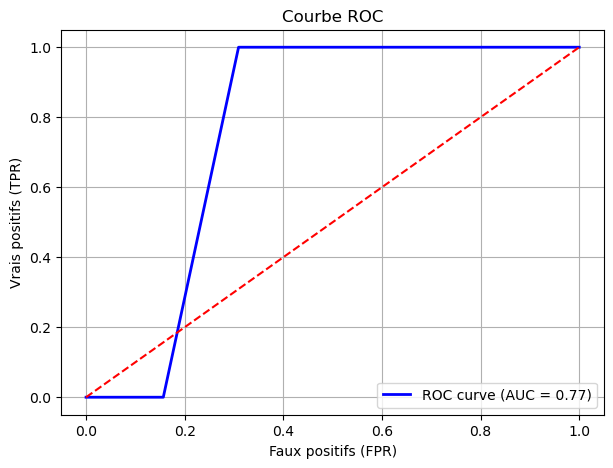

In [105]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# ------------------------
# 1️⃣ Définition et entraînement du modèle
# ------------------------
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)  # X_train et y_train doivent être définis

# Prédiction
y_pred = model.predict(X_test)

# ------------------------
# 2️⃣ Évaluation classique
# ------------------------
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy : {acc:.3f}")

print("\nRapport de classification :")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("\nMatrice de confusion :")
print(confusion_matrix(y_test, y_pred))

# ------------------------
# 3️⃣ Probabilités et ROC
# ------------------------
y_score = model.predict_proba(X_test)[:, 1]  # colonne de la classe positive

fpr, tpr, thresholds = roc_curve(y_test, y_score, pos_label=1)  # ou "High"
roc_auc = auc(fpr, tpr)
print(f"AUC : {roc_auc:.3f}")

# ------------------------
# 4️⃣ Tracé de la courbe ROC
# ------------------------
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # diagonale
plt.xlabel("Faux positifs (FPR)")
plt.ylabel("Vrais positifs (TPR)")
plt.title("Courbe ROC")
plt.legend(loc="lower right")
plt.grid()
plt.show()



In [106]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


X = df.drop(columns=["risk_category", "diabetes"])  # exclure la cible et autres variables non pertinentes
y = df["risk_category"]

# 3. Encodage si nécessaire (pour les colonnes catégorielles)
categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# 4. Normalisation (optionnelle mais recommandée pour certains modèles)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Split train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# 6. Création et entraînement du modèle
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 7. Prédictions
y_pred = clf.predict(X_test)

# 8. Évaluation
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))
print("\nRapport de classification :")
print(classification_report(y_test, y_pred))

Matrice de confusion :
[[  0   0   6]
 [  0 106  12]
 [  0  19  57]]

Rapport de classification :
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         6
         Low       0.85      0.90      0.87       118
    Moderate       0.76      0.75      0.75        76

    accuracy                           0.81       200
   macro avg       0.54      0.55      0.54       200
weighted avg       0.79      0.81      0.80       200



Optimiser le paramètre K

Meilleur k trouvé : 13
Score moyen (CV) : 0.824

Accuracy (test) : 0.84


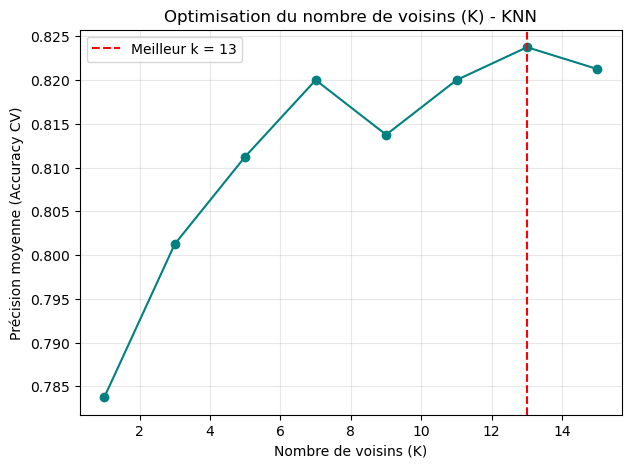

In [110]:
from sklearn.model_selection import GridSearchCV

# Définition des valeurs possibles de k
param_grid = {'n_neighbors': list(range(1, 16, 2))}

# Validation croisée (5 folds)
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

# Meilleur k
best_k = grid.best_params_['n_neighbors']
best_acc = grid.best_score_

print(f"Meilleur k trouvé : {best_k}")
print(f"Score moyen (CV) : {best_acc:.3f}")

# Réévaluation sur le jeu de test
best_knn = grid.best_estimator_
y_pred_best = best_knn.predict(X_test)
print("\nAccuracy (test) :", accuracy_score(y_test, y_pred_best))

import matplotlib.pyplot as plt
# Récupération des résultats complets du GridSearch
results = pd.DataFrame(grid.cv_results_)

# Extraire k et le score moyen associé
k_values = results['param_n_neighbors']
mean_scores = results['mean_test_score']

# Visualisation
plt.figure(figsize=(7,5))
plt.plot(k_values, mean_scores, marker='o', linestyle='-', color='teal')
plt.title("Optimisation du nombre de voisins (K) - KNN")
plt.xlabel("Nombre de voisins (K)")
plt.ylabel("Précision moyenne (Accuracy CV)")
plt.grid(alpha=0.3)
plt.axvline(best_k, color='red', linestyle='--', label=f"Meilleur k = {best_k}")
plt.legend()
plt.show()



Interprétation:

Cela signifie que, d’après la validation croisée (GridSearchCV), le modèle KNN est le plus performant avec k = 13,
c’est-à-dire en regardant les 13 voisins les plus proches pour classer chaque individu.
Score moyen (CV) = 0.824 :Cela signifie que, pendant l’entraînement, le modèle prédit correctement 82,4 % des cas en moyenne sur les sous-échantillons testés.
Accuracy (test) = 0.84 :C’est la précision finale du modèle (avec le meilleur k=13) sur le jeu de test, c’est-à-dire sur des données jamais vues pendant l’entraînement.Le modèle classe correctement 82,4 % des individus du jeu de test.

Ces résultats suggèrent que le modèle KNN parvient à distinguer efficacement les classes cibles avec un faible taux d’erreur .
La proximité entre les scores de validation croisée et de test montre que le modèle n’est pas surappris (pas d’overfitting), et qu’il est hautement fiable pour la prédiction.




conclusion:
Au cours de ce projet, nous avons appliqué des méthodes de classification, de régression et de clustering pour analyser nos données.

Classification :

L’accuracy, le F1-score et la courbe ROC/AUC ont permis d’évaluer la performance globale et la capacité de discrimination des modèles.

Régression :

Les modèles ont capturé les tendances générales des variables continues, avec des erreurs acceptables.

Les mesures comme RMSE, MAE et R² ont permis d’évaluer la précision et la qualité des prédictions.

Clustering :

Plusieurs méthodes ont été utilisées : CAH, KMeans et GMM.

Les clusters obtenus ont permis de segmenter les données, révélant des sous-groupes intéressants.

La sélection du nombre optimal de clusters a été guidée par des critères comme le Silhouette Score, le BIC et le AIC, et les résultats ont été visualisés via PCA.

En synthèse :
Les analyses ont permis de mieux comprendre la structure des données et d’identifier les points forts et limites des modèles. Des améliorations restent possibles, notamment pour gérer les classes déséquilibrées en classification et les valeurs extrêmes en régression.